# Anomaly Detection - CPG Paid Media Panel

A CPG company's paid-media analytics team currently investigates every reporting spike by hand: check
leading indicators, decide whether it's brand-specific or company-wide, separate a genuine efficiency
gain from a mix shift or a spend change, and write up a narrative for the business. That process takes
days per spike and doesn't scale. This notebook builds and validates a statistical detector that
automates the first step of that checklist: deciding whether a month's move on a series is worth an
analyst's time at all.

The panel tracks five primary business metrics for every business unit (BU), brand, and channel, each
month:

| Metric | What it is |
|---|---|
| `roas` | Return on Ad Spend: `reported_revenue / spend`. |
| `rroi` | An ROI-style efficiency ratio built directly from media-attributable sales, `mas / spend` - unlike ROAS, it has no reporting/attribution-inflation layer on top of it. |
| `iroas` | Incremental ROAS: an estimate of the revenue that would *not* have happened without advertising, versus a counterfactual baseline. Because that counterfactual isn't directly observed, iROAS carries more measurement noise than the other four metrics. |
| `mas` | Media-Attributable Sales: `conversions x average order value`. |
| `spend` | Media spend. |

Four leading indicators accompany them: click-through rate (`ctr = clicks / impressions`), cost per
click (`cpc = spend / clicks`), a post-impression conversion rate (`picr = conversions / impressions`),
and `impression_share` (the share of eligible impressions actually won).

Rather than assume ROAS - the brief's headline example - is the metric worth monitoring in production,
this notebook builds the same detector generically across all five, evaluates each one the same way, and
selects the metric to use from that evidence. **Result: RROI, not ROAS, is the metric recommended for
production monitoring** - see Section 9 for the comparison and the reasoning.

Ground truth files (`ground_truth.csv`, `ground_truth_full.csv`, `ground_truth_events.csv`) are never
read, loaded, or referenced anywhere in this notebook - every result below is unsupervised or validated
against synthetic injections and a noisy descriptive tag, never against the true labels.

This notebook is the technical companion to `design_proposal.md` at the repository root, which is the
primary deliverable and carries the business case. This notebook shows the method and the evidence
behind each claim the proposal makes.

## The ask

- **Stakeholder and decision**: the analyst who runs the monthly manual spike check. A flag from this
  detector routes a series to that analyst for review - it does not trigger any automated spend or
  budget action.
- **Cost of a false positive vs. a false negative**: a false positive costs roughly 2-4 analyst-hours of
  triage on a series that was actually fine. A false negative risks a real spike going unreviewed, which
  can misinform a media-reallocation decision - assumed to cost more than a wasted triage hour, which is
  why the detector below leans toward precision rather than trying to catch everything.
- **Deployability**: this is designed as a monthly batch job that feeds the analyst's existing checklist,
  not a real-time or autonomous system.

## Approach

- **Detector**: a robust dual test applied to whichever metric is being scored - a level-shift test
  (catches sudden, one-month jumps) and a trend-break test (catches gradual, three-month ramps), each a
  z-score computed from a 12-month trailing window using the median and median absolute deviation (MAD)
  rather than the mean and standard deviation, so one outlier already sitting in the window doesn't dull
  the test for the next month. A flag requires both a statistical signal (z > 2.5) and a business-relevant
  move (a percent change past that metric's own noise floor - Section 4), so the detector doesn't flag
  statistically real but practically trivial noise.
- **Trivial baseline** (required comparison): a plain mean/std z-score, no trend-break test. Established
  once, on ROAS (Section 5), since the finding it supports - robust scoring beats naive scoring - is a
  property of the method, not of any one metric.
- **Metric selection**: the detector above is run separately on all five primary metrics, and the metric
  used in production is chosen with a synthetic-injection recall/false-positive-rate test (Sections 8-9),
  not assumed from the brief's example.
- **Short-history handling**: series with under 12 months of data are excluded from every metric's
  detector and flagged for manual review instead of being scored on a shakier basis; series with enough
  history get the full test above (Section 2 shows how the panel's 42 series break down).
- **Evaluation without clean labels**: synthetic shocks injected into copies of real series, scored for
  recall and false-positive rate (Section 8), since no ground-truth labels exist to validate against
  directly. A noisy analyst-tag field provides a secondary, descriptive cross-check, reported as
  supporting context in the metric-selection table (Section 9).


## 1. Setup and data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 30)

# Palette: fixed-order categorical hues, colorblind-checked pair (blue/orange), used consistently
COLOR_PRIMARY = '#2E5FA3'    # detector / primary series
COLOR_SECONDARY = '#D9791E'  # baseline / comparison series
COLOR_FLAG = '#C0392B'       # flagged points
COLOR_MUTED = '#8C8C8C'      # unflagged / context

bm = pd.read_csv('../data/brief_metrics.csv', parse_dates=['month']).sort_values(['bu', 'brand', 'channel', 'month']).reset_index(drop=True)
print('Loaded brief_metrics.csv:', bm.shape)
# Shape check kept loose (row count, not exact rows x cols) since the exercise brief allows the
# generator to keep evolving; a hard-coded row count would break on any future regeneration.
assert bm.shape[0] > 1000 and bm.shape[1] == 13, 'unexpected shape -- data file may have changed'

METRICS = ['roas', 'rroi', 'iroas', 'mas', 'spend']              # the 5 brief primary metrics
LEADING_INDICATORS = ['ctr', 'cpc', 'picr', 'impression_share']  # the 4 brief leading indicators
CHOSEN_METRIC = 'rroi'  # set in Section 9 from the evaluation results; declared here for reuse below

bm.head()

Loaded brief_metrics.csv: (1642, 13)


,bu,brand,channel,month,roas,rroi,iroas,mas,spend,ctr,cpc,picr,impression_share
0,Beverages,AquaPure,audio,2022-01-01,5.352246,5.288161,4.532170,24321.050217,4599.151133,0.003439,0.701518,0.000978,0.515922
1,Beverages,AquaPure,audio,2022-02-01,6.070247,5.946743,NaN,21021.337275,3534.933128,0.003227,0.627763,0.000967,0.501198
2,Beverages,AquaPure,audio,2022-03-01,7.616151,7.216625,4.663460,33073.570646,4582.969115,0.002926,0.692187,0.001142,0.501701
3,Beverages,AquaPure,audio,2022-04-01,6.707138,6.503207,3.455055,34220.189043,5262.048340,0.003117,0.732672,0.001157,0.503040
4,Beverages,AquaPure,audio,2022-05-01,7.249145,7.045145,3.846694,37481.681371,5320.213962,0.003051,0.733519,0.001263,0.502226


## 2. Exploratory Data Analysis (EDA)

A descriptive pass over the panel's structure, missingness, and series lengths, before any modeling. It
grounds two choices made later: the short-history tiering rule (Section 5) and the per-metric business
floors (Section 4). No section in this notebook uses ground truth.


In [2]:
print('Rows:', len(bm), ' | BUs:', bm['bu'].nunique(), ' | Brands:', bm['brand'].nunique(),
      ' | Channels:', bm['channel'].nunique(), ' | Months:', bm['month'].nunique())
print()
print('NaN counts per column:')
print(bm.isna().sum())

Rows: 1642  | BUs: 3  | Brands: 8  | Channels: 7  | Months: 48

NaN counts per column:
bu                    0
brand                 0
channel               0
month                 0
roas                  5
rroi                  5
iroas               249
mas                   5
spend                 5
ctr                  18
cpc                  19
picr                 17
impression_share     23
dtype: int64


**Takeaway:** 1,642 rows across 42 BU/brand/channel series and 48 months, with 346 nulls across 13
columns. iROAS holds most of them (249 nulls, about 85% coverage), since it's the only metric gated by
whether an incrementality test ran that month. The gap is by design, not a data problem.


In [3]:
series_len = bm.groupby(['bu', 'brand', 'channel']).size().rename('n_months')
print('Series length distribution (42 brand x channel series):')
print(series_len.describe())
print()
print('Series with <24 months (short/irregular history):')
print(series_len[series_len < 24].sort_values().to_string())
n_short = int((series_len < 12).sum())
n_mid = int(((series_len >= 12) & (series_len < 24)).sum())
n_full = int((series_len >= 24).sum())

Series length distribution (42 brand x channel series):
count    42.000000
mean     39.095238
std      13.423332
min       6.000000
25%      31.000000
50%      48.000000
75%      48.000000
max      48.000000
Name: n_months, dtype: float64

Series with <24 months (short/irregular history):
bu         brand      channel
HomeCare   GlowSkin   ooh        6
Beverages  AquaPure   ooh        8
HomeCare   CleanWave  ooh        8
Snacks     CrispBite  ooh        8


**Takeaway:** 4 series fall under 12 months of history (excluded tier: out-of-home channels that
report only in November and December by design), 0 fall in the 12-24 month band, and 38 have 24+ months
(full dual-test tier). The empty 12-24 month tier stays in the pipeline for a future, shorter panel.


## 3. Detector functions

Two z-score tests, applied to two transformations of whichever metric column is passed in:
month-over-month change for sudden spikes, and 3-month cumulative change for gradual ramps. The same
math is reused for all five metrics - generalizing only changes which column feeds in, not the
statistics themselves.

**Naive test (trivial baseline).** Standard z-score against the trailing window's mean and standard
deviation:

$$z_{\text{naive}}(t) = \frac{r_t - \bar{r}_{t-W:t-1}}{s_{t-W:t-1}}$$

**Robust test (primary detector).** Same structure, with median and MAD (median absolute deviation) in
place of mean and standard deviation:

$$z_{\text{robust}}(t) = \frac{r_t - \text{median}(r_{t-W:t-1})}{1.4826 \times \text{MAD}(r_{t-W:t-1})}, \qquad \text{MAD}(x) = \text{median}(|x - \text{median}(x)|)$$

The 1.4826 factor scales MAD to match a standard deviation under normality, so the same z-thresholds
(2.5, 3.0) apply to both tests. Median/MAD stay anchored to the typical months even with an outlier
already sitting in the window, which is why the robust test is primary and the naive test is only the
trivial-baseline comparison (established once on ROAS in Section 5, not re-derived per metric).

Both tests use `.shift(1)` before the rolling window, so the baseline at month $t$ uses only months
before $t$ (look-ahead safe).


In [4]:
import math

def min_periods_for(win):
    """75% of window, floor 3 -- tolerates a couple of missing months (the panel's incidental
    missingness, plus iROAS's own sparsity) instead of requiring the window to be 100% complete."""
    return max(3, math.ceil(win * 0.75))

def nanmedian_raw(x):
    x = x[~np.isnan(x)]
    return np.nan if len(x) == 0 else np.median(x)

def mad_std_raw(x):
    """Median Absolute Deviation, scaled to be a consistent estimator of std under normality (x1.4826)."""
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan
    med = np.median(x)
    mad = np.median(np.abs(x - med)) * 1.4826
    # Floor MAD instead of returning NaN at 0: a flat window followed by a real move should score as
    # anomalous, not go unscored. 1e-4 is well below any metric's observed MoM noise floor here, so it
    # only engages on a truly flat window.
    return max(mad, 1e-4)

def naive_z(pct_change, win):
    """Trivial baseline: non-robust mean/std z-score. Look-ahead safe."""
    mp = min_periods_for(win)
    m = pct_change.shift(1).rolling(win, min_periods=mp).mean()
    s = pct_change.shift(1).rolling(win, min_periods=mp).std()
    return (pct_change - m) / s

def robust_z(pct_change, win):
    """Primary test building block: median/MAD-based z-score. Look-ahead safe."""
    mp = min_periods_for(win)
    med = pct_change.shift(1).rolling(win, min_periods=mp).apply(nanmedian_raw, raw=True)
    mad = pct_change.shift(1).rolling(win, min_periods=mp).apply(mad_std_raw, raw=True)
    return (pct_change - med) / mad

Smoke tests for the functions above, checking two failure modes before they're used on real data:

In [5]:
# Smoke test 1: a manufactured level shift should score |z| > threshold.
_test = pd.Series([1.0]*13 + [2.0])
_z = robust_z(_test.pct_change(), 12)
print('Smoke test 1 -- manufactured level shift:')
print(_z.tail(1))
assert abs(_z.iloc[-1]) > 2.5, 'detector failed to flag an obvious manufactured level shift'
print('PASS')

# Smoke test 2: same shift, with one prior month set to NaN. Should still fire.
_test2 = _test.copy()
_test2.iloc[5] = np.nan
_z2 = robust_z(_test2.pct_change(), 12)
print('\nSmoke test 2 -- same shift, one missing prior month:')
print(_z2.tail(1))
assert abs(_z2.iloc[-1]) > 2.5, 'detector went blind after a single missing month in the window'
print('PASS')

Smoke test 1 -- manufactured level shift:
13    10000.0
dtype: float64
PASS

Smoke test 2 -- same shift, one missing prior month:
13    10000.0
dtype: float64
PASS


## 4. Per-metric business floor

A single shared noise floor doesn't work across metrics with different volatility: MAS and spend are
structurally noisier than ROAS and RROI, and iROAS adds a measurement-noise layer on top of its own
volatility because it estimates an unobserved counterfactual rather than measuring something directly.
Each metric gets its own floor instead: the 75th percentile of its own observed month-over-month noise.


In [6]:
floor_rows = []
for m in METRICS:
    mom = bm.groupby(['bu', 'brand', 'channel'])[m].pct_change(fill_method=None).dropna()
    mom = mom.replace([np.inf, -np.inf], np.nan).dropna()  # a handful of near-zero denominators produce inf
    floor_rows.append({
        'metric': m,
        'n_pairs': len(mom),
        'median_abs_pct': mom.abs().median(),
        'p75_abs_pct': mom.abs().quantile(0.75),
        'p90_abs_pct': mom.abs().quantile(0.90),
    })

floor_table = pd.DataFrame(floor_rows).set_index('metric')
print(floor_table.round(3))

# BUSINESS_FLOORS: each metric's own p75 |MoM %change|, rounded to the nearest whole percent.
BUSINESS_FLOORS = (floor_table['p75_abs_pct'] * 100).round().div(100).to_dict()
print('\nBUSINESS_FLOORS (per-metric, rounded to nearest 1%):')
for m, f in BUSINESS_FLOORS.items():
    print(f'  {m}: {f*100:.0f}%')

        n_pairs  median_abs_pct  p75_abs_pct  p90_abs_pct
metric                                                   
roas       1593           0.087        0.145        0.210
rroi       1593           0.086        0.141        0.206
iroas      1157           0.220        0.368        0.533
mas        1593           0.109        0.219        0.386
spend      1593           0.123        0.236        0.417

BUSINESS_FLOORS (per-metric, rounded to nearest 1%):
  roas: 15%
  rroi: 14%
  iroas: 37%
  mas: 22%
  spend: 24%


**Takeaway:** RROI's floor (14%) lands close to ROAS's (15%), consistent with
`roas = rroi * attribution_inflation`. MAS and spend are noisier (22-24%). iROAS's floor is highest by
far (37%), not a data-sparsity artifact (1,157 valid month-over-month pairs, close to the ~1,593 the
other metrics have) but the direct effect of its own measurement-noise layer on top of its underlying
volatility.


## 5. Generic tiered scoring pipeline - all 5 metrics

`score_metric` scores one series on one metric column with the same tiering, window, and z-logic
regardless of which metric or floor is passed in. iROAS runs through this same generic path, missingness
and measurement noise included, rather than being special-cased: one code path for all five metrics.

| Tier | Available history | Test(s) | Window | $z^*$ |
|---|---:|---|---:|---:|
| excluded | $n < 12$ months | none | -- | -- |
| sparse | $12 \leq n < 24$ months | naive level-shift test | 6 months | 3.0 |
| full | $n \geq 24$ months | robust level-shift + trend-break | 12 months | 2.5 |

A month is flagged when either test exceeds the statistical threshold and the corresponding move also
exceeds that metric's own business floor from Section 4.


In [7]:
MIN_HIST_EXCLUDE = 12    # series shorter than this: excluded due to insufficient history
MIN_HIST_FULL    = 24    # series with at least this many months: full dual-test tier
SPARSE_WIN       = 6     # trailing window (months), 12-24mo tier
FULL_WIN         = 12    # trailing window (months), 24mo+ tier -- spans one seasonal year
SPARSE_Z         = 3.0   # wider-tolerance cutoff, 12-24mo tier (noisier baseline, so demand more evidence)
FULL_Z           = 2.5   # threshold, fixed across all 5 metrics (precision-leaning; see the sensitivity table on ROAS in the proposal)

def score_metric(g, metric_col, floor):
    """Compute tier assignment, z-scores, and flags for one (bu, brand, channel) series, on one metric
    column. Business-floor thresholds apply on both the MoM % change (level-shift) and the 3-month
    cumulative % change (trend-break) -- same floor for both, a stated simplification rather than two
    tuned floors, since there's no labeled data to justify two different numbers."""
    g = g.sort_values('month').reset_index(drop=True)
    n = len(g)

    if n < MIN_HIST_EXCLUDE:
        tier = 'excluded'
    elif n < MIN_HIST_FULL:
        tier = 'sparse'
    else:
        tier = 'full'

    val = g[metric_col]
    mom = val.pct_change(fill_method=None)
    cum3 = val.pct_change(3, fill_method=None)

    g['tier'] = tier
    g['mom_pct'] = mom
    g['cum3_pct'] = cum3

    if tier == 'sparse':
        g['z_stat'] = naive_z(mom, SPARSE_WIN)
        g['z_trend'] = np.nan  # not enough history for a stable 3-month trend baseline
        stat_flag = g['z_stat'].abs() > SPARSE_Z
        biz_flag = g['mom_pct'].abs() >= floor
        g['flagged'] = stat_flag & biz_flag
        g['flag_type'] = np.where(g['flagged'], 'level_shift', None)
    elif tier == 'full':
        g['z_stat'] = robust_z(mom, FULL_WIN)
        g['z_trend'] = robust_z(cum3, FULL_WIN)
        level_flag = (g['z_stat'].abs() > FULL_Z) & (g['mom_pct'].abs() >= floor)
        trend_flag = (g['z_trend'].abs() > FULL_Z) & (g['cum3_pct'].abs() >= floor)
        g['flagged'] = level_flag | trend_flag
        g['flag_type'] = np.select(
            [level_flag & trend_flag, level_flag, trend_flag],
            ['both', 'level_shift', 'trend_break'],
            default=None,
        )
    else:  # excluded
        g['z_stat'] = np.nan
        g['z_trend'] = np.nan
        g['flagged'] = False
        g['flag_type'] = None

    # Naive comparison, same input/window/threshold/floor as robust scoring -- isolates naive mean/std
    # vs. robust median/MAD. Established once on ROAS just below, not re-derived per metric, since the
    # point (robust beats naive) is a property of the method, not of any one metric.
    g['z_naive_baseline'] = np.nan
    g['naive_baseline_flagged'] = False
    if tier == 'full':
        g['z_naive_baseline'] = naive_z(mom, FULL_WIN)
        g['naive_baseline_flagged'] = (
            (g['z_naive_baseline'].abs() > FULL_Z)
            & (g['mom_pct'].abs() >= floor)
        )

    return g

def score_all_series(metric_col, floor):
    # Manual per-group loop, not groupby().apply(): recent pandas versions drop the grouping columns
    # from the sub-frame passed into apply()'d functions, which breaks downstream joins on bu/brand/channel.
    parts = [score_metric(g.copy(), metric_col, floor) for _, g in bm.groupby(['bu', 'brand', 'channel'])]
    return pd.concat(parts, ignore_index=True)

scored_by_metric = {m: score_all_series(m, BUSINESS_FLOORS[m]) for m in METRICS}

print('Tier assignment (identical across metrics -- depends on series length, not metric):')
print(scored_by_metric['roas'].groupby(['bu', 'brand', 'channel'])['tier'].first().value_counts())
print()

print('Flags per metric:')
for m in METRICS:
    sc = scored_by_metric[m]
    scoreable = sc['tier'].ne('excluded').sum()
    print(f'  {m:>6}: {sc["flagged"].sum():4d} flags / {scoreable} scoreable rows (floor={BUSINESS_FLOORS[m]*100:.0f}%)')

Tier assignment (identical across metrics -- depends on series length, not metric):
tier
full        38
excluded     4
Name: count, dtype: int64

Flags per metric:
    roas:  151 flags / 1612 scoreable rows (floor=15%)
    rroi:  137 flags / 1612 scoreable rows (floor=14%)
   iroas:   66 flags / 1612 scoreable rows (floor=37%)
     mas:  218 flags / 1612 scoreable rows (floor=22%)
   spend:  203 flags / 1612 scoreable rows (floor=24%)


**Takeaway:** flag counts range from 66 (iROAS: tightest coverage, widest floor) to 218 (MAS). Raw
flag count isn't a useful comparison across metrics on its own, since each has a different floor and
coverage. Sections 8 and 9 evaluate detection quality directly instead.


### Robust vs. naive scoring (ROAS, established once)

For the full-history tier, robust and naive level-shift scoring are compared on ROAS: same
month-over-month change, 12-month window, $z^*=2.5$, and ROAS's own business floor. The only difference
is the reference statistic (median/MAD versus mean/std). This validates the method itself, so the
comparison isn't repeated per metric.


In [8]:
roas_full = scored_by_metric['roas'][scored_by_metric['roas']['tier'] == 'full']
robust_level = (roas_full['z_stat'].abs() > FULL_Z) & (roas_full['mom_pct'].abs() >= BUSINESS_FLOORS['roas'])
naive_level = roas_full['naive_baseline_flagged']

print(f"Full-tier robust level-shift flags: {robust_level.sum()}")
print(f"Full-tier naive level-shift flags:  {naive_level.sum()}")
print(f"Robust only: {(robust_level & ~naive_level).sum()}")
print(f"Naive only:  {(naive_level & ~robust_level).sum()}")

Full-tier robust level-shift flags: 74
Full-tier naive level-shift flags:  48
Robust only: 33
Naive only:  7


**Takeaway:** robust scoring catches more level shifts on ROAS (74 vs. 48) with almost no loss (7
naive-only). Median/MAD staying anchored despite an outlier already in the window is a real advantage on
this data, not a marginal one.


## 6. Per-metric coverage check

How much of each metric's rolling window has enough data to compute a z-score, for full-tier series. A
low flag count should be read against this: "not enough data to say" is a different finding than
"nothing is happening."


In [9]:
coverage_rows = []
for m in METRICS:
    sc = scored_by_metric[m]
    full = sc[sc['tier'] == 'full']
    n_scoreable = len(full)
    n_scored = full['z_stat'].notna().sum()
    coverage_rows.append({
        'metric': m,
        'full_tier_rows': n_scoreable,
        'rows_with_a_z_score': n_scored,
        'coverage_pct': 100 * n_scored / n_scoreable if n_scoreable else float('nan'),
    })

coverage_table = pd.DataFrame(coverage_rows).set_index('metric')
print(coverage_table.round(1))

        full_tier_rows  rows_with_a_z_score  coverage_pct
metric                                                   
roas              1612                 1220          75.7
rroi              1612                 1220          75.7
iroas             1612                  507          31.5
mas               1612                 1220          75.7
spend             1612                 1220          75.7


**Takeaway:** iROAS gets a usable z-score on only 31.5% of its nominal full-tier rows, versus 75.7%
for the other four (which share the same ~3% incidental missingness). The 75.7% floor is normal
rolling-window warm-up; iROAS's 31.5% is the real structural gap, on top of the noise layer from
Section 4.


## 7. Per-metric leading-indicator corroboration

The brief requires the detector to use the four leading indicators, not just a headline metric. For each
primary metric's flagged rows, this counts how many of the four leading indicators also cross the same
z-threshold in the same month: a 0-4 corroboration score, computed **independently per primary metric**.
This is evidence strength, not a cause label; cause attribution is a separate exercise component.


In [10]:
def corroboration_count(row, series_df, indicators):
    win = FULL_WIN if row['tier'] == 'full' else SPARSE_WIN
    z_thresh = FULL_Z if row['tier'] == 'full' else SPARSE_Z
    zfun = robust_z if row['tier'] == 'full' else naive_z

    count, checked = 0, 0
    for col in indicators:
        z = zfun(series_df[col].pct_change(), win)
        val = z.get(row.name, np.nan)
        if not np.isnan(val):
            checked += 1
            count += abs(val) > z_thresh
    return count, checked

corrob_summary = {}
for m in METRICS:
    sc = scored_by_metric[m]
    flagged_idx = sc.index[sc['flagged']]
    rows = []
    for idx in flagged_idx:
        row = sc.loc[idx]
        mask = (sc['bu'] == row['bu']) & (sc['brand'] == row['brand']) & (sc['channel'] == row['channel'])
        c, checked = corroboration_count(row, sc.loc[mask], LEADING_INDICATORS)
        rows.append((idx, c, checked))
    cdf = pd.DataFrame(rows, columns=['idx', 'corrob_count', 'corrob_checked']).set_index('idx')
    scored_by_metric[m] = sc.join(cdf)

    n_flags = len(flagged_idx)
    zero = int((scored_by_metric[m].loc[flagged_idx, 'corrob_count'] == 0).sum()) if n_flags else 0
    two_plus = int((scored_by_metric[m].loc[flagged_idx, 'corrob_count'] >= 2).sum()) if n_flags else 0
    mean_c = scored_by_metric[m].loc[flagged_idx, 'corrob_count'].mean() if n_flags else float('nan')
    corrob_summary[m] = {'n_flags': n_flags, 'zero_corrob': zero, 'two_plus_corrob': two_plus, 'mean_corrob': mean_c}

corrob_df = pd.DataFrame(corrob_summary).T
print(corrob_df.round(2))

       n_flags  zero_corrob  two_plus_corrob  mean_corrob
roas     151.0         78.0             27.0         0.70
rroi     137.0         70.0             26.0         0.72
iroas     66.0         43.0              7.0         0.45
mas      218.0        145.0             31.0         0.50
spend    203.0        122.0             34.0         0.60


**Takeaway:** RROI and ROAS flags get corroborated most often (mean ~0.7 of 4 indicators), iROAS
and MAS least (~0.45-0.50). This is consistent with iROAS's own noise and coverage gaps, and with MAS and
spend's wider floors letting through moves the leading indicators don't echo as often.


## 8. Per-metric evaluation - synthetic injection recall / false-positive rate (FPR)

No ground truth exists to check the detector against, so this section manufactures anomalies with a
known answer and checks whether the detector catches them. **What gets modified is a copy of one real
series' actual metric values**, not synthetic or simulated data. The worked example below shows exactly
what that means before the full evaluation runs it 1,140 times.


In [11]:
# Worked example: what "injecting a shock" means, on one real series and RROI. Illustrative only --
# the actual evaluation below uses all 38 full-tier series, all 5 metrics, and randomized target months.
example_key = ('Beverages', 'AquaPure', 'audio')
example_series = bm[(bm['bu'] == example_key[0]) & (bm['brand'] == example_key[1])
                     & (bm['channel'] == example_key[2])].sort_values('month').reset_index(drop=True)

target_i = 20   # an arbitrary illustrative month with enough trailing history before it
shock = 0.40    # matches the brief's own "ROAS jumps 40%" example

print(f'Real RROI, {"/".join(example_key)}, the target month and the 2 before it:')
print(example_series[['month', 'rroi']].iloc[target_i - 2:target_i + 1].to_string(index=False))

real_val = example_series['rroi'].iloc[target_i]
print(f'\nSudden injection changes only the target month: {real_val:.2f} -> {real_val * (1 + shock):.2f} '
      f'(real value x {1 + shock:.2f})')

print('\nGradual injection ramps the same shock in over the target month and the 2 before it:')
for step, i in enumerate([target_i - 2, target_i - 1, target_i], start=1):
    v = example_series['rroi'].iloc[i]
    mult = 1 + shock * step / 3
    print(f'  {example_series["month"].iloc[i].date()}: {v:.2f} -> {v * mult:.2f} (x{mult:.2f}, {step}/3 of the shock)')

Real RROI, Beverages/AquaPure/audio, the target month and the 2 before it:
     month     rroi
2023-07-01 6.158854
2023-08-01 5.379152
2023-09-01 6.516343

Sudden injection changes only the target month: 6.52 -> 9.12 (real value x 1.40)

Gradual injection ramps the same shock in over the target month and the 2 before it:
  2023-07-01: 6.16 -> 6.98 (x1.13, 1/3 of the shock)
  2023-08-01: 5.38 -> 6.81 (x1.27, 2/3 of the shock)
  2023-09-01: 6.52 -> 9.12 (x1.40, 3/3 of the shock)


**Takeaway:**

- Every other month in the copy stays untouched, real data. Only the target month (sudden), or the
  target month and the 2 before it (gradual), get multiplied by the shock.
- The same detector from Section 5 scores the modified copy. "Detected" means its flag landed on the
  target month (or, for gradual, on any of the 3 ramp months).
- Repeated for 3 shock sizes x 2 onset types x 38 series x 5 metrics = 1,140 manufactured tests. The same
  38 series and target months (same random seed) are reused across metrics, so the five metrics' recall
  numbers are a fair head-to-head.
- FPR is the mirror image: run the detector on the same 38 series with no injection, and count every flag
  as a false positive by construction.
- Caveat: a genuine unlabeled anomaly already in the real data would also count as a false positive here,
  a limitation of not having ground truth, not of the method.


### How recall and FPR are computed

- **Recall**: of the events we manufactured, how many did the detector catch?

$$\text{Recall} = \frac{\text{trials flagged}}{38}$$

  One injected event per series (38 series = 38 trials), computed separately for each of the 3 shock
  sizes and both onset types: 38 x 3 x 2 = 228 trials per metric, 1,140 across all 5 metrics.

- **FPR**: of the ordinary, untouched months, how many did the detector flag anyway?

$$\text{FPR} = \frac{\text{flagged months, no injection}}{1{,}612 \text{ scoreable months}}$$

  Same 38 series, real unmodified values. One number per metric, not split by shock size, since no shock
  is involved.

The denominators differ on purpose: 38 for recall, 1,612 for FPR. The two rates measure different things
and aren't comparable side by side.


In [12]:
def inject_sudden(g, target_i, shock, metric_col):
    """Copy one real series and multiply its value at target_i by (1 + shock) -- a one-month jump."""
    g = g.copy()
    g.loc[g.index[target_i], metric_col] *= (1 + shock)
    return g

def inject_gradual(g, end_i, shock, metric_col):
    """Copy one real series and ramp the same shock in over end_i and the 2 months before it -- a
    three-month build instead of a single jump."""
    g = g.copy()
    for step, i in enumerate([end_i - 2, end_i - 1, end_i], start=1):
        g.loc[g.index[i], metric_col] *= (1 + shock * step / 3)
    return g

SHOCK_SIZES = [0.20, 0.30, 0.40]  # matches the brief's own example magnitude ("ROAS jumps 40%")
RNG_SEED = 42  # reproducible; only used for synthetic injection, never for detection itself

full_tier_keys = scored_by_metric['roas'][scored_by_metric['roas']['tier'] == 'full'].groupby(
    ['bu', 'brand', 'channel']).size().index.tolist()
base_keys = full_tier_keys  # all 38 full-tier series
print(f'{len(base_keys)} full-tier series will each get one injected event per shock size, per metric.')

38 full-tier series will each get one injected event per shock size, per metric.


The loop below runs this calculation once per metric: for each of the 38 series, it computes the
real (unmodified) FPR contribution, then injects each of the 3 shock sizes at a randomly chosen month,
sudden and gradual, and records whether the detector caught it.


In [13]:
eval_summary = {}
recall_tables = {}
for m in METRICS:
    floor = BUSINESS_FLOORS[m]
    rng = np.random.default_rng(RNG_SEED)  # reset per metric so the same shock placement is used across metrics
    sudden_results, gradual_results = [], []
    negative_flags, negative_rows = 0, 0   # accumulate the FPR numerator/denominator across all 38 series

    for key in base_keys:
        base = bm[(bm['bu'] == key[0]) & (bm['brand'] == key[1]) & (bm['channel'] == key[2])].sort_values('month').reset_index(drop=True)
        n = len(base)
        # Only inject where the metric itself is observed at the target month and 2 months prior
        # (handles iROAS's residual missingness -- a shock on a NaN month is a no-op, not a real test).
        candidate_range = [i for i in range(FULL_WIN + 3, n)
                            if pd.notna(base[m].iloc[i]) and pd.notna(base[m].iloc[max(0, i - 2)])]
        if len(candidate_range) == 0:
            continue

        # FPR contribution from this series: score the real, unmodified data and count every flag.
        scored_neg = score_metric(base.copy(), m, floor)
        negative_flags += scored_neg['flagged'].sum()
        negative_rows += scored_neg['tier'].ne('excluded').sum()

        # Recall contribution from this series: one injected trial per shock size, sudden and gradual.
        for shock in SHOCK_SIZES:
            target_i = rng.choice(candidate_range)

            scored_sudden = score_metric(inject_sudden(base, target_i, shock, m), m, floor)
            sudden_results.append({'key': key, 'shock': shock, 'detected': bool(scored_sudden.loc[target_i, 'flagged'])})

            scored_gradual = score_metric(inject_gradual(base, target_i, shock, m), m, floor)
            lo = max(0, target_i - 2)
            detected_g = bool(scored_gradual.loc[lo:target_i, 'flagged'].any())
            gradual_results.append({'key': key, 'shock': shock, 'detected': detected_g})

    # Recall per shock size = the fraction of the 38 trials at that shock size where 'detected' was True --
    # averaging a True/False column directly gives that fraction.
    sudden_df = pd.DataFrame(sudden_results)
    gradual_df = pd.DataFrame(gradual_results)
    recall_table = pd.DataFrame({
        'sudden_recall': sudden_df.groupby('shock')['detected'].mean(),
        'gradual_recall': gradual_df.groupby('shock')['detected'].mean(),
    })
    recall_tables[m] = recall_table

    # FPR = total false flags / total scoreable rows, across all 38 series, no shock involved.
    fpr = negative_flags / negative_rows if negative_rows else float('nan')

    eval_summary[m] = {
        'recall_40_sudden': recall_table.loc[0.4, 'sudden_recall'],
        'recall_40_gradual': recall_table.loc[0.4, 'gradual_recall'],
        'recall_20_sudden': recall_table.loc[0.2, 'sudden_recall'],
        'recall_20_gradual': recall_table.loc[0.2, 'gradual_recall'],
        'fpr': fpr,
        'n_negative_rows': negative_rows,
    }
    print(f'--- {m} ---')
    print(recall_table.round(3))
    print(f'FPR: {negative_flags}/{negative_rows} = {fpr*100:.1f}%\n')

eval_df = pd.DataFrame(eval_summary).T
print('=== Evaluation summary, all metrics ===')
print(eval_df.round(3))

--- roas ---
       sudden_recall  gradual_recall
shock                               
0.2            0.447           0.474
0.3            0.579           0.447
0.4            0.684           0.553
FPR: 151/1612 = 9.4%



--- rroi ---
       sudden_recall  gradual_recall
shock                               
0.2            0.342           0.474
0.3            0.553           0.605
0.4            0.737           0.553
FPR: 137/1612 = 8.5%



--- iroas ---
       sudden_recall  gradual_recall
shock                               
0.2            0.158           0.237
0.3            0.263           0.316
0.4            0.158           0.158
FPR: 66/1612 = 4.1%



--- mas ---
       sudden_recall  gradual_recall
shock                               
0.2            0.316           0.368
0.3            0.474           0.342
0.4            0.342           0.447
FPR: 218/1612 = 13.5%



--- spend ---
       sudden_recall  gradual_recall
shock                               
0.2            0.237           0.316
0.3            0.474           0.395
0.4            0.447           0.342
FPR: 203/1612 = 12.6%

=== Evaluation summary, all metrics ===
       recall_40_sudden  recall_40_gradual  recall_20_sudden  recall_20_gradual    fpr  n_negative_rows
roas              0.684              0.553             0.447              0.474  0.094           1612.0
rroi              0.737              0.553             0.342              0.474  0.085           1612.0
iroas             0.158              0.158             0.158              0.237  0.041           1612.0
mas               0.342              0.447             0.316              0.368  0.135           1612.0
spend             0.447              0.342             0.237              0.316  0.126           1612.0


**Takeaway:** recall broadly rises with shock size, but not monotonically for every metric: RROI's gradual recall runs 47.4% / 60.5% / 55.3% across the 20/30/40% shocks, and MAS and spend are also non-monotone. With 38 series and one injected event each, single-cell moves of this size are sampling noise, not a property of the detector. RROI and ROAS reach the highest recall at a 40% shock (73.7% and 68.4% sudden); iROAS barely clears 16% even at that size. FPR ranges from 4.1% (iROAS) to 13.5% (MAS). Section 9 reads these two numbers together, since a low FPR from a detector that rarely fires isn't the same as a precise one.


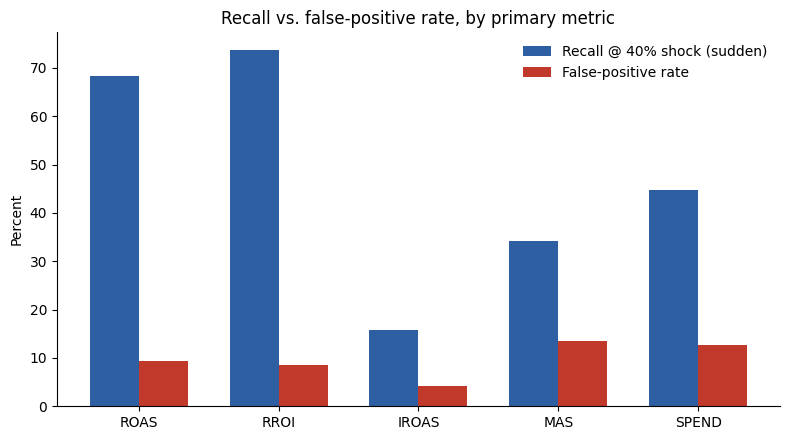

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(METRICS))
width = 0.35
ax.bar(x - width/2, eval_df['recall_40_sudden'] * 100, width, color=COLOR_PRIMARY, label='Recall @ 40% shock (sudden)')
ax.bar(x + width/2, eval_df['fpr'] * 100, width, color=COLOR_FLAG, label='False-positive rate')
ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in METRICS])
ax.set_ylabel('Percent')
ax.set_title('Recall vs. false-positive rate, by primary metric')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Takeaway:** RROI and ROAS are the only metrics with high recall and low FPR at the same time. MAS
and spend trade FPR for a bit of recall, and iROAS is low on both, a detection failure, not a precision
win (see Section 9).


## 9. Metric selection

Recall and FPR (Section 8) drive the choice of which metric to run in production. Coverage (Section 6),
business floor (Section 4), corroboration (Section 7), and tag overlap are shown alongside as supporting
context, not blended into a single score. Recall wants a high number, FPR wants a low number, and a noise
floor has no inherent "good" direction, so combining them into one weighted number would require a
weighting scheme no stakeholder has specified: an arbitrary choice dressed up as a formula.


In [15]:
# Fixed display order (not sorted by value): RROI and ROAS first since they're the primary and
# secondary picks, then the remaining three.
METRIC_ORDER = ['rroi', 'roas', 'spend', 'mas', 'iroas']

ASSESSMENT = {
    'rroi':  'Primary (recommended)',
    'roas':  'Secondary (corroboration)',
    'spend': 'Higher FPR, no recall edge',
    'mas':   'Higher FPR, no recall edge',
    'iroas': 'Low recall (noise-limited)',
}

decision_criteria = pd.DataFrame({
    'recall_sudden_40_pct': eval_df['recall_40_sudden'] * 100,
    'recall_gradual_40_pct': eval_df['recall_40_gradual'] * 100,
    'recall_sudden_20_pct': eval_df['recall_20_sudden'] * 100,
    'recall_gradual_20_pct': eval_df['recall_20_gradual'] * 100,
    'fpr_pct': eval_df['fpr'] * 100,
}).loc[METRIC_ORDER]
decision_criteria['assessment'] = pd.Series(ASSESSMENT)
decision_criteria.index = decision_criteria.index.str.upper()

print('=== Decision criteria (recall / FPR -- drives the selection) ===')
print(decision_criteria.round(1))

=== Decision criteria (recall / FPR -- drives the selection) ===
       recall_sudden_40_pct  recall_gradual_40_pct  recall_sudden_20_pct  recall_gradual_20_pct  fpr_pct                  assessment
RROI                   73.7                   55.3                  34.2                   47.4      8.5       Primary (recommended)
ROAS                   68.4                   55.3                  44.7                   47.4      9.4   Secondary (corroboration)
SPEND                  44.7                   34.2                  23.7                   31.6     12.6  Higher FPR, no recall edge
MAS                    34.2                   44.7                  31.6                   36.8     13.5  Higher FPR, no recall edge
IROAS                  15.8                   15.8                  15.8                   23.7      4.1  Low recall (noise-limited)


In [16]:
pdf_tags = pd.read_csv('../data/panel_data_full.csv', parse_dates=['month'])[['bu', 'brand', 'channel', 'month', 'analyst_tag']]
tag_overlap = {}
for m in METRICS:
    sc_tagged = scored_by_metric[m].merge(pdf_tags, on=['bu', 'brand', 'channel', 'month'], how='left')
    tagged = sc_tagged['analyst_tag'].notna()
    n_flags_m = sc_tagged['flagged'].sum()
    overlap_m = (tagged & sc_tagged['flagged']).sum()
    tag_overlap[m] = overlap_m / n_flags_m * 100 if n_flags_m else float('nan')

supporting_context = pd.DataFrame({
    'n_flags': {m: int(scored_by_metric[m]['flagged'].sum()) for m in METRICS},
    'floor_pct': {m: BUSINESS_FLOORS[m] * 100 for m in METRICS},
    'coverage_pct': coverage_table['coverage_pct'],
    'mean_corrob': corrob_df['mean_corrob'],
    'tag_overlap_pct': pd.Series(tag_overlap),
}).loc[METRIC_ORDER]
supporting_context.index = supporting_context.index.str.upper()

print('=== Supporting context (informative, not blended into the decision) ===')
print(supporting_context.round(1))

=== Supporting context (informative, not blended into the decision) ===
       n_flags  floor_pct  coverage_pct  mean_corrob  tag_overlap_pct
RROI       137       14.0          75.7          0.7             24.8
ROAS       151       15.0          75.7          0.7             27.2
SPEND      203       24.0          75.7          0.6             23.6
MAS        218       22.0          75.7          0.5             28.9
IROAS       66       37.0          31.5          0.5             24.2


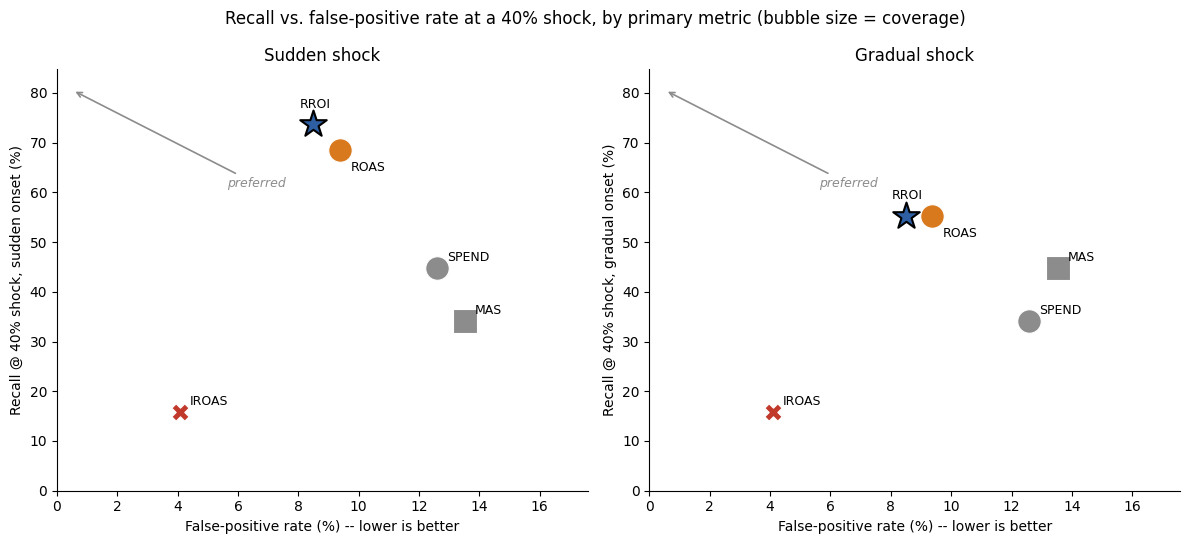

Saved metric_selection_recall_fpr.png


In [17]:
METRIC_STYLE = {
    # color/marker per metric: RROI is the recommended primary (star, emphasized outline), ROAS the
    # secondary corroboration signal, iROAS gets a distinct marker/color since its low FPR is a caveat,
    # not a strength (see the note below the plot).
    'rroi':  {'color': COLOR_PRIMARY,   'marker': '*', 'emphasize': True},
    'roas':  {'color': COLOR_SECONDARY, 'marker': 'o', 'emphasize': False},
    'spend': {'color': COLOR_MUTED,     'marker': 'o', 'emphasize': False},
    'mas':   {'color': COLOR_MUTED,     'marker': 's', 'emphasize': False},
    'iroas': {'color': COLOR_FLAG,      'marker': 'X', 'emphasize': False},
}

def bubble_size(cov_pct):
    """Bubble area encodes coverage (Section 6): linear in percent, floored at 60pt^2 so iROAS's
    31.5% coverage stays visible next to the other four's 75.7%."""
    return 60 + cov_pct * 3

# Same axis limits on both panels, derived from the data (with padding) rather than hardcoded, so the
# scale doesn't need to change if the evaluation numbers ever change.
recall_all_pct = pd.concat([eval_df['recall_40_sudden'], eval_df['recall_40_gradual']]) * 100
fpr_all_pct = eval_df['fpr'] * 100
xlim = (0, fpr_all_pct.max() * 1.3)
ylim = (0, recall_all_pct.max() * 1.15)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
panel_specs = [
    (axes[0], 'recall_40_sudden', 'Recall @ 40% shock, sudden onset (%)', 'Sudden shock'),
    (axes[1], 'recall_40_gradual', 'Recall @ 40% shock, gradual onset (%)', 'Gradual shock'),
]

# RROI and ROAS sit close together on both panels (similar recall/FPR) -- offset their labels in
# opposite directions so they don't overlap each other; the other three are spaced out naturally.
LABEL_OFFSET = {'rroi': (-10, 12), 'roas': (8, -15), 'spend': (7, 5), 'mas': (7, 5), 'iroas': (7, 5)}

for ax, recall_col, ylabel, title in panel_specs:
    for m in METRICS:
        style = METRIC_STYLE[m]
        x = eval_df.loc[m, 'fpr'] * 100
        y = eval_df.loc[m, recall_col] * 100
        size = bubble_size(coverage_table.loc[m, 'coverage_pct'])
        edge, lw, mult, z = ('black', 1.5, 1.4, 5) if style['emphasize'] else ('white', 0.8, 1.0, 3)
        ax.scatter(x, y, s=size * mult, marker=style['marker'], color=style['color'],
                   edgecolor=edge, linewidth=lw, zorder=z)
        ax.annotate(m.upper(), (x, y), xytext=LABEL_OFFSET[m], textcoords='offset points', fontsize=9)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('False-positive rate (%) -- lower is better')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.annotate('preferred', xy=(0.03, 0.95), xytext=(0.32, 0.72), xycoords='axes fraction',
                textcoords='axes fraction', arrowprops=dict(arrowstyle='->', color=COLOR_MUTED, lw=1.2),
                fontsize=9, color=COLOR_MUTED, style='italic')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Recall vs. false-positive rate at a 40% shock, by primary metric (bubble size = coverage)')
plt.tight_layout()
plt.savefig('metric_selection_recall_fpr.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved metric_selection_recall_fpr.png')

**Note:** iROAS's FPR (4.1%), the lowest of the five, is not evidence of a more precise detector.
Its recall is also the lowest (about 16% even at a 40% shock), because the detector rarely fires on
iROAS at all, a direct result of its own measurement noise (Section 4) and 31.5% coverage (Section 6). A
detector that almost never fires will always look precise on FPR alone; this reflects iROAS's noise and
missingness, not that iROAS is a weak business metric.


**Chosen primary metric: RROI.** RROI has the highest sudden-shock recall (73.7% vs. ROAS's 68.4%),
ties ROAS on gradual-shock recall (55.3%), and has a slightly lower FPR (8.5% vs. 9.4%). Spend and MAS
both carry a higher FPR (12.6%, 13.5%) without a compensating recall advantage over RROI or ROAS.

RROI is selected as the primary production metric. ROAS is retained as the secondary corroboration
signal: `roas / rroi = attribution_inflation` is itself a useful `measurement_artifact` signal.


## 10. RROI - example flagged series, visualized

One example series, selected for showing all three flag types rather than just the most total flags,
with flagged months marked: circle = level-shift (sudden), triangle = trend-break (gradual), square =
both tests fired. This is a visual sanity check, not the evaluation; see Sections 8 and 9 for that.


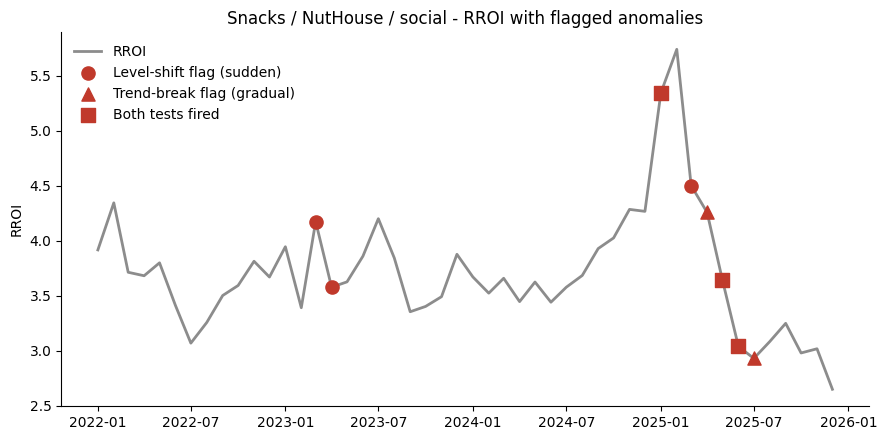

In [18]:
scored = scored_by_metric[CHOSEN_METRIC]
flagged_idx = scored.index[scored['flagged']]

# Pick an example series that shows all three flag types -- a series with only one flag type would
# make the legend's three marker shapes misleading.
flag_diversity = scored.loc[flagged_idx].groupby(['bu', 'brand', 'channel'])['flag_type'].nunique()
diverse_candidates = flag_diversity[flag_diversity == 3].index

flag_counts = scored.loc[flagged_idx].groupby(['bu', 'brand', 'channel']).size()
if len(diverse_candidates) > 0:
    example_key = flag_counts.loc[diverse_candidates].idxmax()
else:
    example_key = flag_counts.idxmax()  # fallback: no series shows all three flag types

ex = scored[(scored['bu'] == example_key[0]) & (scored['brand'] == example_key[1]) & (scored['channel'] == example_key[2])].sort_values('month')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ex['month'], ex[CHOSEN_METRIC], color=COLOR_MUTED, linewidth=2, zorder=1, label=CHOSEN_METRIC.upper())

for ftype, marker, label in [('level_shift', 'o', 'Level-shift flag (sudden)'),
                              ('trend_break', '^', 'Trend-break flag (gradual)'),
                              ('both', 's', 'Both tests fired')]:
    sub = ex[ex['flag_type'] == ftype]
    if len(sub):
        ax.scatter(sub['month'], sub[CHOSEN_METRIC], color=COLOR_FLAG, marker=marker, s=90, zorder=3, label=label)

ax.set_title(f"{example_key[0]} / {example_key[1]} / {example_key[2]} - {CHOSEN_METRIC.upper()} with flagged anomalies")
ax.set_ylabel(CHOSEN_METRIC.upper())
ax.legend(loc='upper left', frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Takeaway:** flags cluster where RROI visibly departs from its recent trailing pattern; trend-break
flags catch multi-month drifts the eye would read as gradual, not a single spike.


## 11. Final outputs

Flagged-anomaly tables for every metric (the artifacts an analyst would consume), plus the summary
numbers cited in `proposal_anomaly_detection.md`. `flagged_anomalies.csv` is the canonical output (RROI's
flags, the chosen primary metric); ROAS and the other three non-chosen metrics each get their own
`flagged_<metric>.csv`.


In [19]:
output_cols = ['bu', 'brand', 'channel', 'month', 'tier', 'flag_type', 'mom_pct', 'cum3_pct',
               'corrob_count', 'corrob_checked']

for m in METRICS:
    sc = scored_by_metric[m]
    idx = sc.index[sc['flagged']]
    tbl = sc.loc[idx, output_cols].sort_values(['bu', 'brand', 'channel', 'month'])
    fname = 'flagged_anomalies.csv' if m == CHOSEN_METRIC else f'flagged_{m}.csv'
    tbl.to_csv(fname, index=False)
    print(f'Wrote {fname}: {len(tbl)} rows ({m}{" -- CHOSEN PRIMARY METRIC" if m == CHOSEN_METRIC else ""})')

scored.loc[flagged_idx, output_cols].head(10)

Wrote flagged_roas.csv: 151 rows (roas)
Wrote flagged_anomalies.csv: 137 rows (rroi -- CHOSEN PRIMARY METRIC)
Wrote flagged_iroas.csv: 66 rows (iroas)
Wrote flagged_mas.csv: 218 rows (mas)
Wrote flagged_spend.csv: 203 rows (spend)


,bu,brand,channel,month,tier,flag_type,mom_pct,cum3_pct,corrob_count,corrob_checked
12,Beverages,AquaPure,audio,2023-01-01,full,trend_break,-0.248730,-0.255988,3.0,4.0
45,Beverages,AquaPure,audio,2025-10-01,full,trend_break,0.190471,0.396303,2.0,4.0
61,Beverages,AquaPure,display,2023-02-01,full,both,0.369270,0.486487,2.0,4.0
62,Beverages,AquaPure,display,2023-03-01,full,trend_break,-0.092629,0.411642,0.0,4.0
67,Beverages,AquaPure,display,2023-08-01,full,trend_break,-0.156612,-0.315806,0.0,4.0
80,Beverages,AquaPure,display,2024-09-01,full,trend_break,0.351956,0.357034,0.0,4.0
83,Beverages,AquaPure,display,2024-12-01,full,trend_break,0.046968,-0.341194,0.0,4.0
85,Beverages,AquaPure,display,2025-02-01,full,trend_break,0.210294,0.302120,0.0,4.0
146,Beverages,AquaPure,paid_search,2025-07-01,full,level_shift,0.238171,0.251528,0.0,4.0
147,Beverages,AquaPure,paid_search,2025-08-01,full,level_shift,-0.167128,0.124372,0.0,3.0


In [20]:
print('=== SUMMARY (for report) ===')
print(f"Series: 42 total -- {n_short} excluded (insufficient history), {n_mid} sparse-tier, {n_full} full-tier")
print(f"Chosen primary metric: {CHOSEN_METRIC.upper()}")
print(f"Primary detector flags ({CHOSEN_METRIC}): {scored['flagged'].sum()} / {scored['tier'].ne('excluded').sum()} scoreable rows")
print(f"Business floor ({CHOSEN_METRIC}): {BUSINESS_FLOORS[CHOSEN_METRIC]*100:.0f}%")
print(f"Recall @ 40% shock: sudden={eval_df.loc[CHOSEN_METRIC,'recall_40_sudden']*100:.0f}%, "
      f"gradual={eval_df.loc[CHOSEN_METRIC,'recall_40_gradual']*100:.0f}%")
print(f"Recall @ 20% shock: sudden={eval_df.loc[CHOSEN_METRIC,'recall_20_sudden']*100:.0f}%, "
      f"gradual={eval_df.loc[CHOSEN_METRIC,'recall_20_gradual']*100:.0f}%")
print(f"Empirical false-positive rate: {eval_df.loc[CHOSEN_METRIC,'fpr']*100:.1f}%")
print(f"analyst_tag overlap ({CHOSEN_METRIC}): {tag_overlap[CHOSEN_METRIC]:.1f}%")
print(f"ROAS (secondary/corroboration metric) flags: {scored_by_metric['roas']['flagged'].sum()}")
print(f"ROAS full-tier robust-vs-naive: {robust_level.sum()} vs {naive_level.sum()}")

=== SUMMARY (for report) ===
Series: 42 total -- 4 excluded (insufficient history), 0 sparse-tier, 38 full-tier
Chosen primary metric: RROI
Primary detector flags (rroi): 137 / 1612 scoreable rows
Business floor (rroi): 14%
Recall @ 40% shock: sudden=74%, gradual=55%
Recall @ 20% shock: sudden=34%, gradual=47%
Empirical false-positive rate: 8.5%
analyst_tag overlap (rroi): 24.8%
ROAS (secondary/corroboration metric) flags: 151
ROAS full-tier robust-vs-naive: 74 vs 48


## 12. Limitations and next steps

- **Metric selection is recall/FPR-driven on this rule-based detector, not a learned classifier.** The
  Section 9 ranking could change if the detector design itself changed (a different window, a different
  robust statistic). It's a fair comparison of this detector across metrics, not a claim that RROI is
  intrinsically the best-behaved metric in the abstract.
- **iROAS's low recall (Sections 8-9) is a measurement-noise and coverage artifact**, not proof iROAS is
  an unstable business metric. Restated here because it's the easiest number in this notebook to misread
  out of context.
- **Per-metric business floors (Section 4) are each derived independently** from that metric's own noise
  distribution, not cross-validated against each other or against labeled ground truth.
- **The 12-24 month sparse tier is currently empty** (Section 2), kept in the code for robustness against
  a shorter panel, not because any series exercises it today.
- **The 4 excluded (under 12 month) series are never scored by any metric's detector.** They need either
  a different, shorter-window method or a manual fallback, not a lower bar on the same method.
- **Corroboration counts (Section 7) are associational evidence strength, not a causal claim.** Naming
  which cause is a separate exercise component.
- With more time: re-derive the flags-per-month vs. analyst-hours-per-month sensitivity table per metric
  instead of reusing ROAS's, and validate the sparse-tier 6-month window the same way if a future panel
  brings mid-length series back.
